In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

df = pd.read_csv("/content/dataset.csv")
df.columns = df.columns.str.strip()

fiction = df[df["Genre"] == "Fiction"]
nonfiction = df[df["Genre"] == "Non Fiction"]

palette = {"Fiction": "#e05c5c", "Non Fiction": "#4a90d9"}

def save(name):
    plt.tight_layout()
    plt.show()
    plt.close()



**Q1 **bold text**. Plot a line chart showing the average user rating per year
for Fiction and Non-Fiction books separately. Identify whether
one genre consistently outrates the other.**

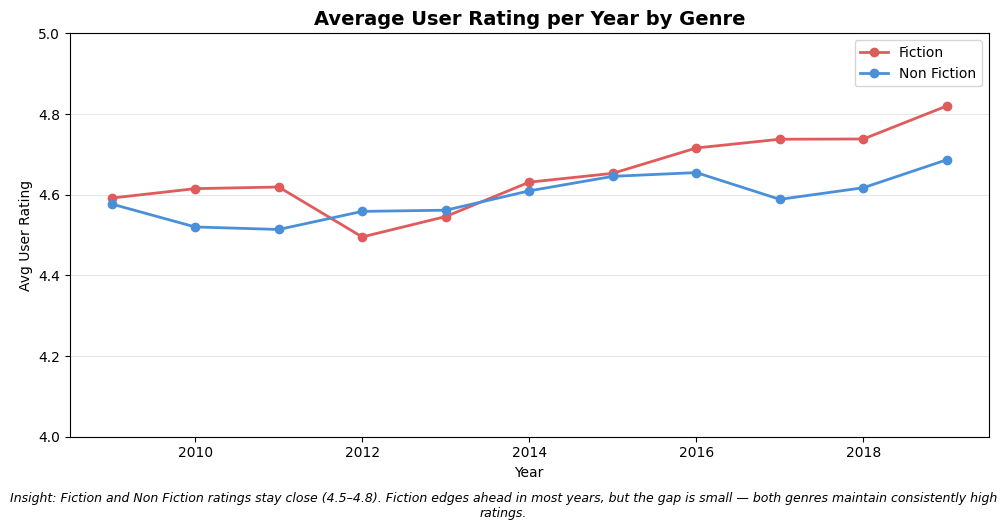

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
for genre, color in palette.items():
    g = df[df["Genre"] == genre].groupby("Year")["User Rating"].mean()
    ax.plot(g.index, g.values, marker="o", label=genre, color=color, linewidth=2)
ax.set_title("Average User Rating per Year by Genre", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Avg User Rating")
ax.legend()
ax.set_ylim(4.0, 5.0)
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: Fiction and Non Fiction ratings stay close (4.5–4.8). "
    "Fiction edges ahead in most years, but the gap is small — both genres maintain consistently high ratings.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q1_line_rating_by_year")

Insight: Fiction and Non Fiction ratings stay close (4.5–4.8). Fiction edges ahead in most years, but the gap is small — both genres maintain consistently high ratings.

**Q2. Create a scatter plot of &#39;Price&#39; vs. &#39;Reviews&#39; for all books.
Color points by Genre. Use log scale for Reviews. Identify high-
value, high-engagement outliers.**

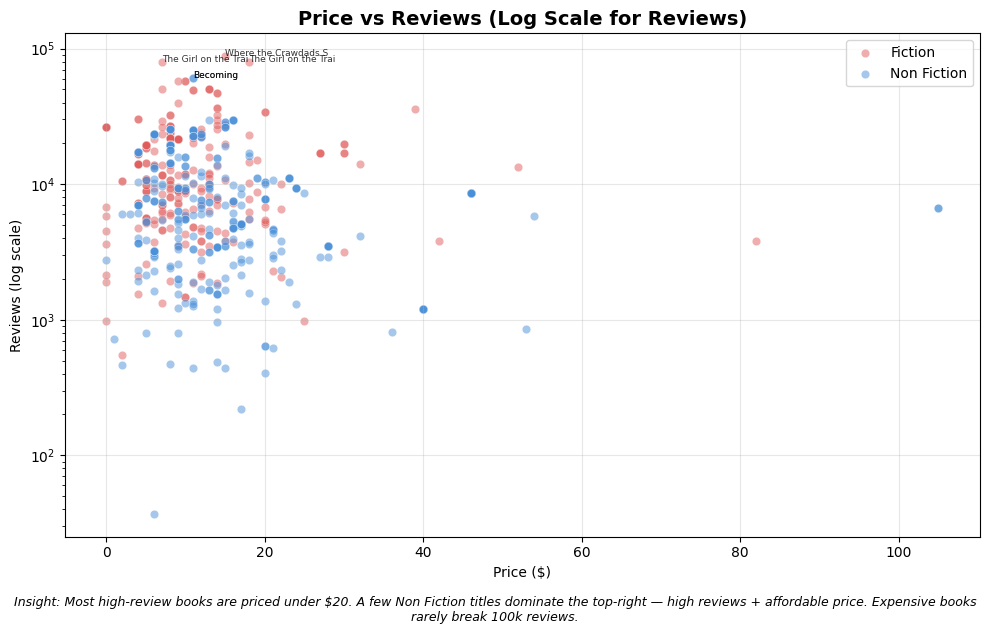

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
for genre, color in palette.items():
    g = df[df["Genre"] == genre]
    ax.scatter(g["Price"], g["Reviews"], alpha=0.5, color=color, label=genre, edgecolors="white", linewidth=0.3)
ax.set_xscale("linear")
ax.set_yscale("log")
ax.set_title("Price vs Reviews (Log Scale for Reviews)", fontsize=14, fontweight="bold")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Reviews (log scale)")
ax.legend()
ax.grid(alpha=0.3)
top = df.nlargest(5, "Reviews")
for _, row in top.iterrows():
    ax.annotate(row["Name"][:20], (row["Price"], row["Reviews"]), fontsize=6.5, alpha=0.8)
fig.text(0.5, -0.04,
    "Insight: Most high-review books are priced under $20. "
    "A few Non Fiction titles dominate the top-right — high reviews + affordable price. "
    "Expensive books rarely break 100k reviews.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q2_scatter_price_reviews")


Insight: Most high-review books are priced under $20. A few Non Fiction titles dominate the top-right — high reviews + affordable price. Expensive books rarely break 100k reviews.

**Q3. Visualize the distribution of book prices using a histogram.
Overlay KDE curves for Fiction and Non-Fiction. Identify the
most common price point for each genre.**

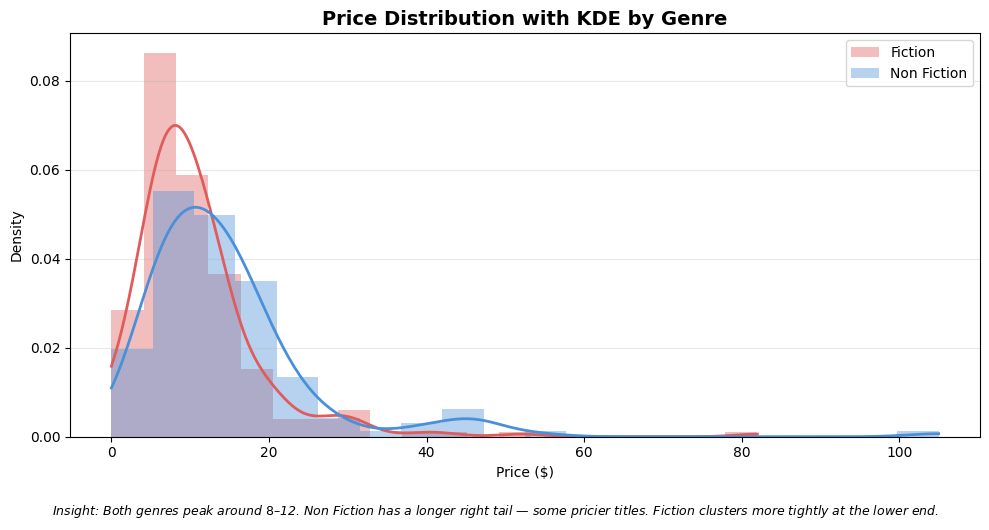

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
for genre, color in palette.items():
    g = df[df["Genre"] == genre]["Price"]
    ax.hist(g, bins=20, alpha=0.4, color=color, label=genre, density=True)
    kde_x = np.linspace(g.min(), g.max(), 300)
    kde = gaussian_kde(g)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2)
ax.set_title("Price Distribution with KDE by Genre", fontsize=14, fontweight="bold")
ax.set_xlabel("Price ($)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: Both genres peak around $8–$12. "
    "Non Fiction has a longer right tail — some pricier titles. "
    "Fiction clusters more tightly at the lower end.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q3_histogram_kde_price")


Insight: Both genres peak around $8–$12. Non Fiction has a longer right tail — some pricier titles. Fiction clusters more tightly at the lower end.

**Q4. Create a density plot of &#39;User Rating&#39; grouped by year
(grouped into periods: 2009–2013, 2014–2019). Identify whether
average quality shifted across periods.**

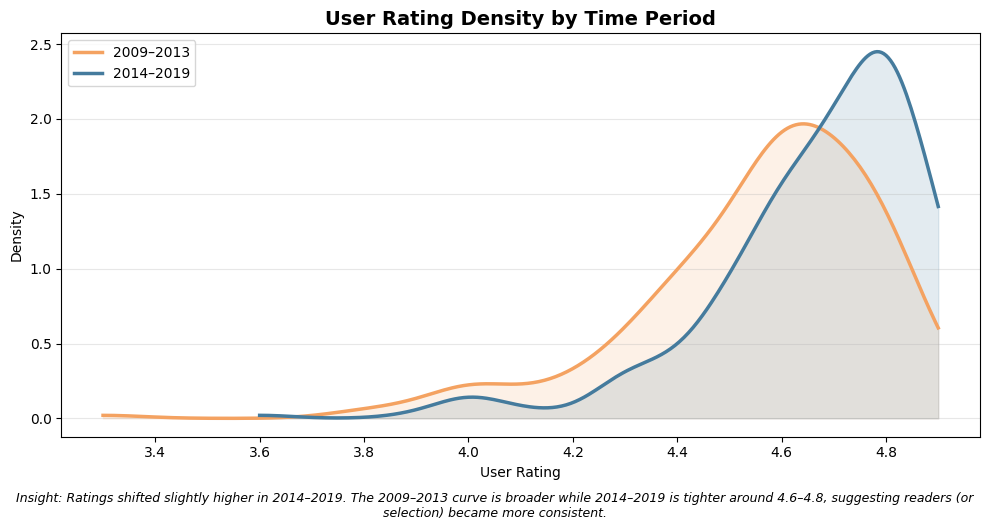

In [18]:

df["Period"] = df["Year"].apply(lambda y: "2009–2013" if y <= 2013 else "2014–2019")
fig, ax = plt.subplots(figsize=(10, 5))
period_palette = {"2009–2013": "#f4a261", "2014–2019": "#457b9d"}
for period, color in period_palette.items():
    g = df[df["Period"] == period]["User Rating"]
    kde_x = np.linspace(g.min(), g.max(), 300)
    kde = gaussian_kde(g)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.5, label=period)
    ax.fill_between(kde_x, kde(kde_x), alpha=0.15, color=color)
ax.set_title("User Rating Density by Time Period", fontsize=14, fontweight="bold")
ax.set_xlabel("User Rating")
ax.set_ylabel("Density")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: Ratings shifted slightly higher in 2014–2019. "
    "The 2009–2013 curve is broader while 2014–2019 is tighter around 4.6–4.8, "
    "suggesting readers (or selection) became more consistent.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q4_density_rating_by_period")

Insight: Ratings shifted slightly higher in 2014–2019. The 2009–2013 curve is broader while 2014–2019 is tighter around 4.6–4.8, suggesting readers (or selection) became more consistent.

**Q5. Use a 2D density contour plot (sns.kdeplot) of &#39;Price&#39; vs.
&#39;Reviews&#39;. Identify clusters of popular affordable vs. expensive
underperforming books.**

/tmp/ipykernel_19046/1747516821.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


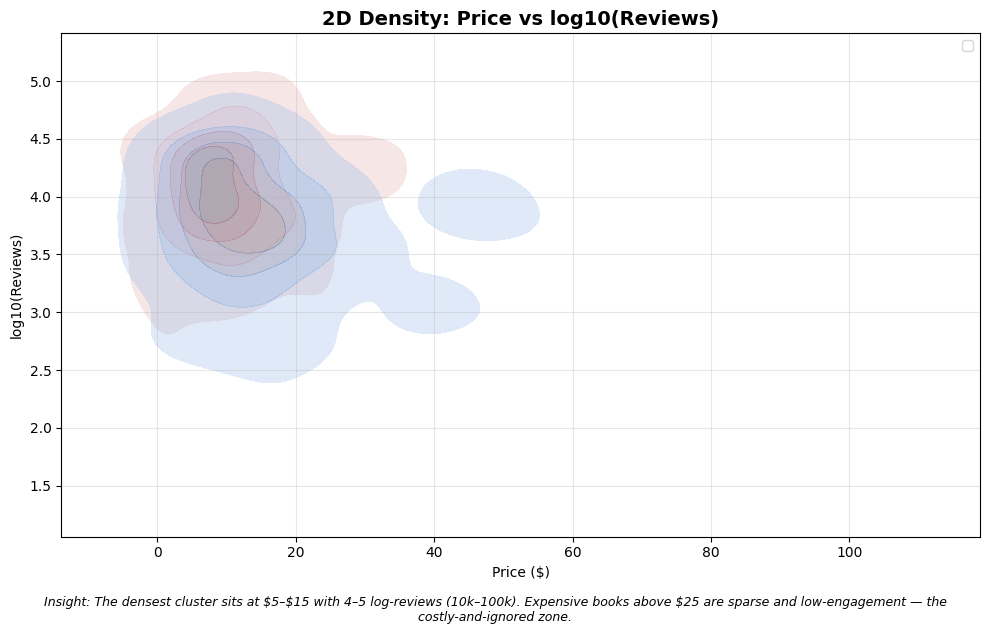

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
for genre, color in palette.items():
    g = df[df["Genre"] == genre]
    sns.kdeplot(x=g["Price"], y=np.log10(g["Reviews"] + 1), ax=ax, color=color, fill=True, alpha=0.3, label=genre, levels=5)
ax.set_title("2D Density: Price vs log10(Reviews)", fontsize=14, fontweight="bold")
ax.set_xlabel("Price ($)")
ax.set_ylabel("log10(Reviews)")
ax.legend()
ax.grid(alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: The densest cluster sits at $5–$15 with 4–5 log-reviews (10k–100k). "
    "Expensive books above $25 are sparse and low-engagement — the costly-and-ignored zone.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q5_2d_density_price_reviews")


Insight: The densest cluster sits at $5–$15 with 4–5 log-reviews (10k–100k). Expensive books above $25 are sparse and low-engagement — the costly-and-ignored zone.

**Q6. Visualize error bars of average price per year (mean ± std).
Determine whether pricing became more or less variable over
the decade.**

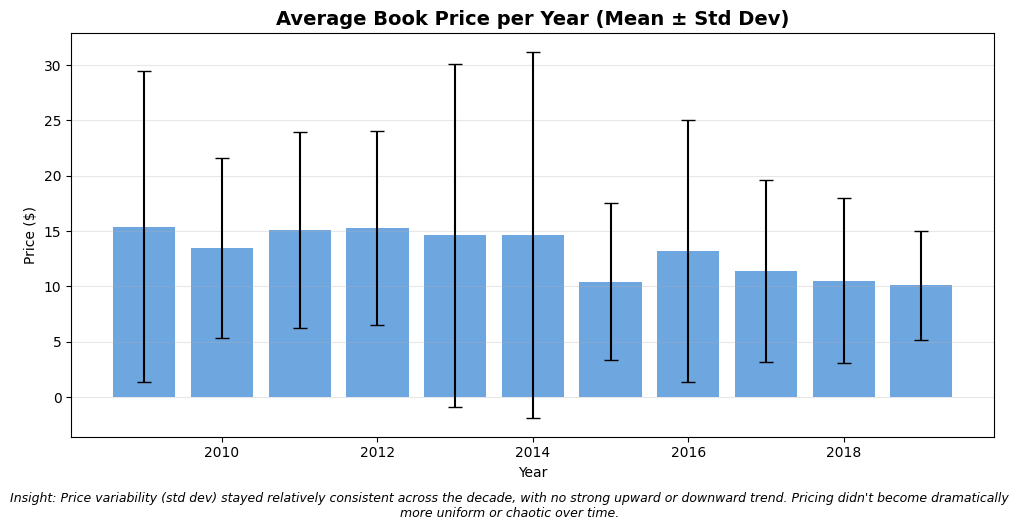

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
year_stats = df.groupby("Year")["Price"].agg(["mean", "std"]).reset_index()
ax.bar(year_stats["Year"], year_stats["mean"], yerr=year_stats["std"],
       color="#4a90d9", alpha=0.8, capsize=5, error_kw={"elinewidth": 1.5})
ax.set_title("Average Book Price per Year (Mean ± Std Dev)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Price ($)")
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: Price variability (std dev) stayed relatively consistent across the decade, "
    "with no strong upward or downward trend. Pricing didn't become dramatically more uniform or chaotic over time.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q6_errorbars_price_per_year")

Insight: Price variability (std dev) stayed relatively consistent across the decade, with no strong upward or downward trend. Pricing didn't become dramatically more uniform or chaotic over time.

**Q7. Build a 2x2 subplot grid: (a) bar chart of top 10 authors by
total reviews, (b) line plot of average price per year, (c) boxplot
of reviews by genre, (d) scatter of rating vs. reviews.**

/tmp/ipykernel_19046/2807416103.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


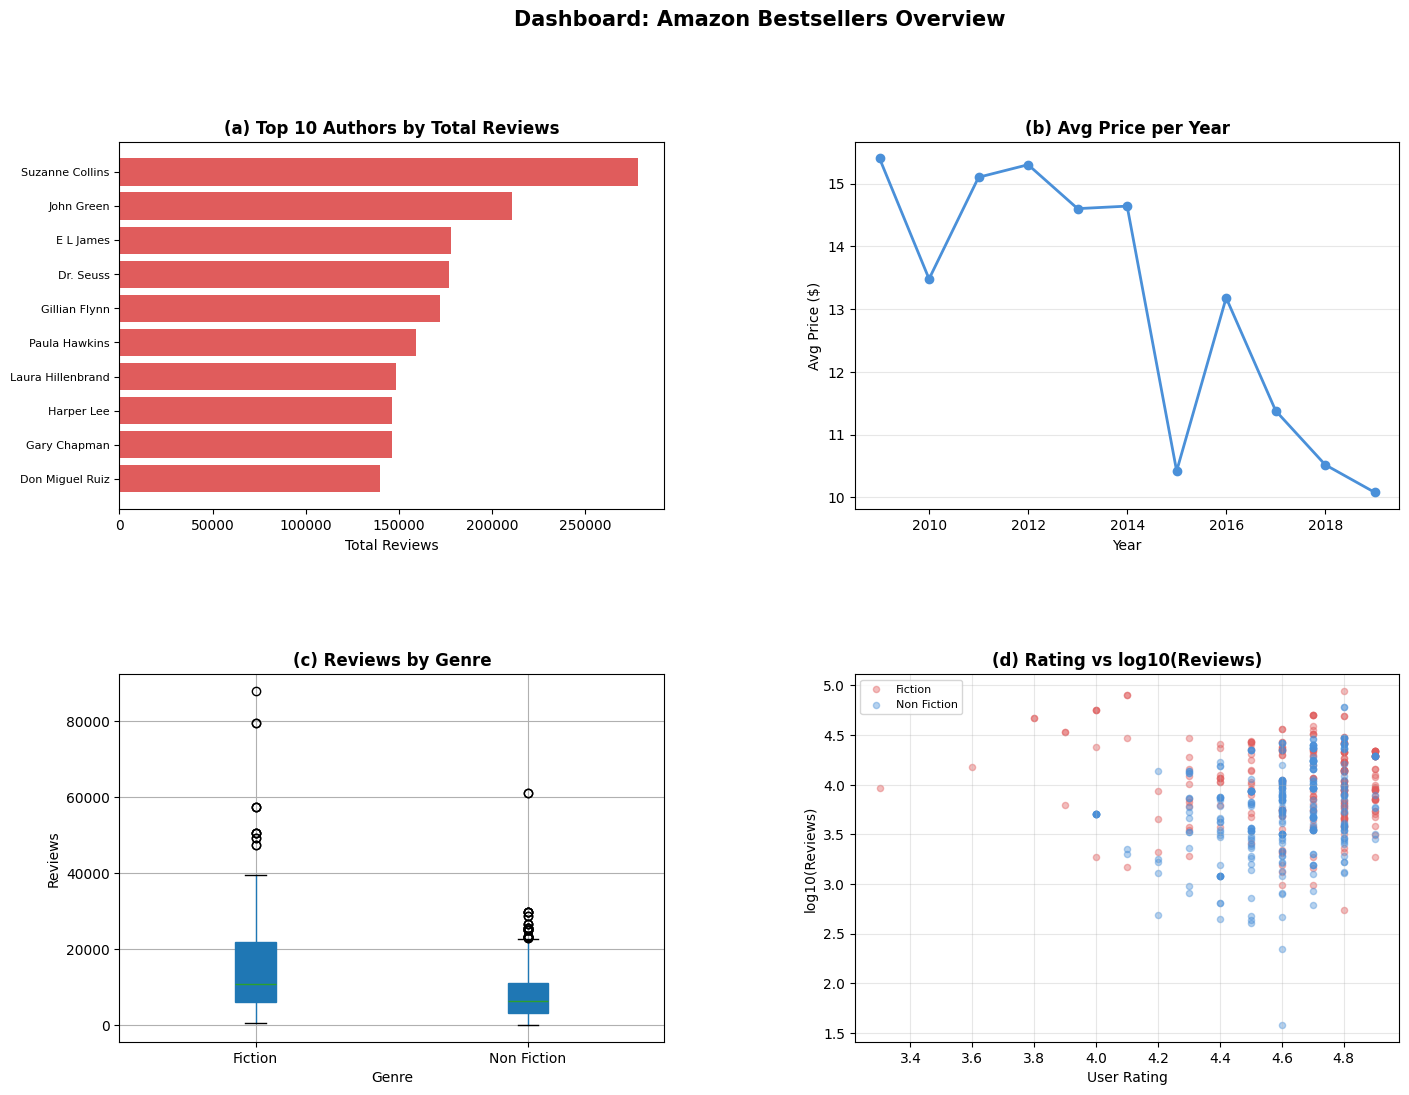

In [21]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
top10 = df.groupby("Author")["Reviews"].sum().nlargest(10).sort_values()
ax1.barh(top10.index, top10.values, color="#e05c5c")
ax1.set_title("(a) Top 10 Authors by Total Reviews", fontweight="bold")
ax1.set_xlabel("Total Reviews")
ax1.tick_params(axis="y", labelsize=8)

ax2 = fig.add_subplot(gs[0, 1])
avg_price = df.groupby("Year")["Price"].mean()
ax2.plot(avg_price.index, avg_price.values, marker="o", color="#4a90d9", linewidth=2)
ax2.set_title("(b) Avg Price per Year", fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Avg Price ($)")
ax2.grid(axis="y", alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
df.boxplot(column="Reviews", by="Genre", ax=ax3, patch_artist=True)
ax3.set_title("(c) Reviews by Genre", fontweight="bold")
ax3.set_xlabel("Genre")
ax3.set_ylabel("Reviews")
plt.sca(ax3)
plt.title("(c) Reviews by Genre", fontweight="bold")
fig.suptitle("")

ax4 = fig.add_subplot(gs[1, 1])
for genre, color in palette.items():
    g = df[df["Genre"] == genre]
    ax4.scatter(g["User Rating"], np.log10(g["Reviews"] + 1), alpha=0.4, color=color, label=genre, s=20)
ax4.set_title("(d) Rating vs log10(Reviews)", fontweight="bold")
ax4.set_xlabel("User Rating")
ax4.set_ylabel("log10(Reviews)")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

fig.suptitle("Dashboard: Amazon Bestsellers Overview", fontsize=15, fontweight="bold", y=1.01)
save("q7_2x2_dashboard")

This dashboard provides a comprehensive overview: top authors by reviews, average price trends, genre-wise review distributions, and the relationship between rating and reviews.

**Q8. Use Seaborn&#39;s stripplot and boxplot (combined) to show
user rating distribution by genre and year bucket. Identify
outliers and rating trends.**

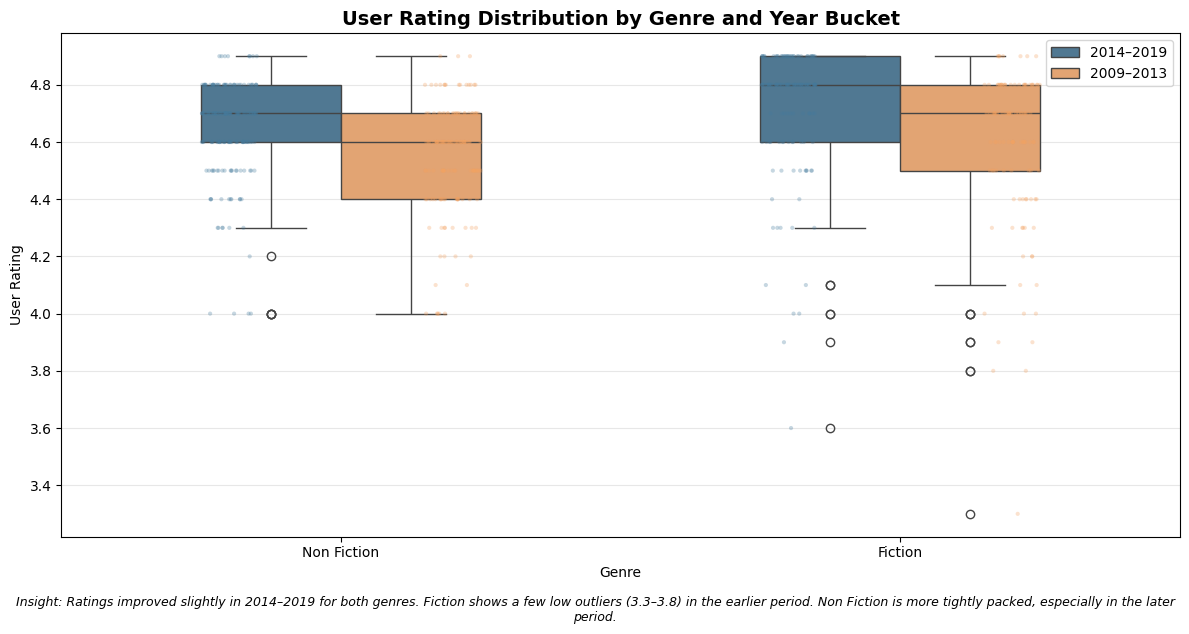

In [22]:
df["Year Bucket"] = df["Year"].apply(lambda y: "2009–2013" if y <= 2013 else "2014–2019")
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x="Genre", y="User Rating", hue="Year Bucket",
            palette={"2009–2013": "#f4a261", "2014–2019": "#457b9d"}, ax=ax, width=0.5)
sns.stripplot(data=df, x="Genre", y="User Rating", hue="Year Bucket",
              palette={"2009–2013": "#f4a261", "2014–2019": "#457b9d"},
              dodge=True, alpha=0.3, jitter=True, ax=ax, size=3, legend=False)
ax.set_title("User Rating Distribution by Genre and Year Bucket", fontsize=14, fontweight="bold")
ax.set_xlabel("Genre")
ax.set_ylabel("User Rating")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2])
ax.grid(axis="y", alpha=0.3)
fig.text(0.5, -0.04,
    "Insight: Ratings improved slightly in 2014–2019 for both genres. "
    "Fiction shows a few low outliers (3.3–3.8) in the earlier period. "
    "Non Fiction is more tightly packed, especially in the later period.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q8_strip_box_rating_genre_year")

Insight: Ratings improved slightly in 2014–2019 for both genres. Fiction shows a few low outliers (3.3–3.8) in the earlier period. Non Fiction is more tightly packed, especially in the later period.

**Q9. Create a Seaborn heatmap of average user rating by Author
(top 20) and Year. Annotate and identify the most consistently
top-rated authors.**

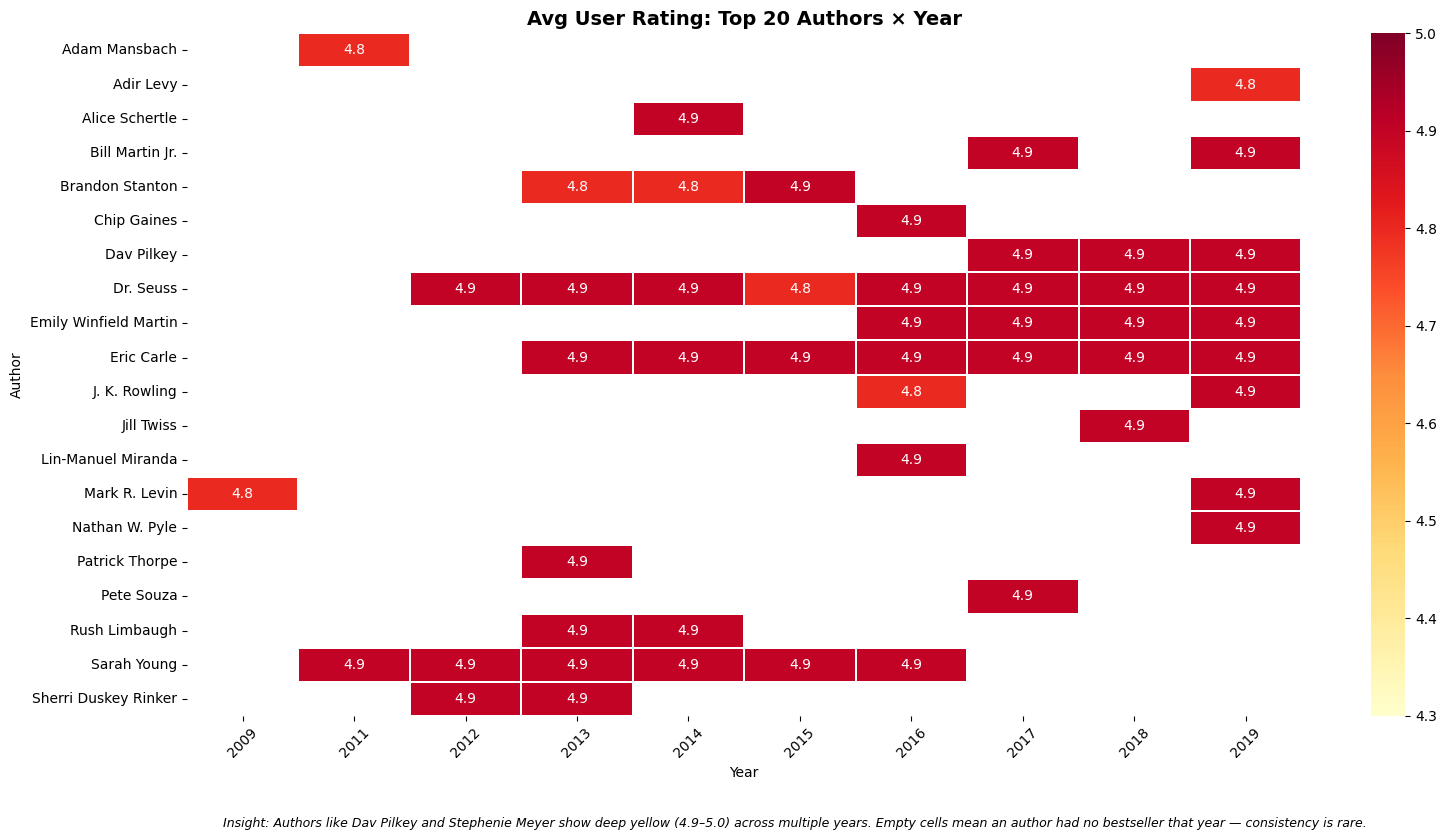

In [23]:
top20_authors = df.groupby("Author")["User Rating"].mean().nlargest(20).index
df_top = df[df["Author"].isin(top20_authors)]
pivot = df_top.pivot_table(values="User Rating", index="Author", columns="Year", aggfunc="mean")
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, linewidths=0.3, vmin=4.3, vmax=5.0)
ax.set_title("Avg User Rating: Top 20 Authors × Year", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Author")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
fig.text(0.5, -0.04,
    "Insight: Authors like Dav Pilkey and Stephenie Meyer show deep yellow (4.9–5.0) across multiple years. "
    "Empty cells mean an author had no bestseller that year — consistency is rare.",
    ha="center", fontsize=9, style="italic", wrap=True)
save("q9_heatmap_author_year")

Insight: Authors like Dav Pilkey and Stephenie Meyer show deep yellow (4.9–5.0) across multiple years. Empty cells mean an author had no bestseller that year — consistency is rare.

**Q10. Use Seaborn&#39;s pairplot on &#39;Price&#39;, &#39;User Rating&#39;, and
&#39;Reviews&#39; grouped by Genre. Identify the relationships that bestseparate Fiction from Non-Fiction.**

In [24]:
df["Genre"] = df["Genre"].str.strip()
pair_df = df[["Price", "User Rating", "Reviews", "Genre"]].copy()
pair_df["log_reviews"] = np.log10(pair_df["Reviews"] + 1)
pair_df = pair_df.drop(columns=["Reviews"])

g = sns.pairplot(pair_df, hue="Genre", palette=palette, plot_kws={"alpha": 0.4, "s": 15},
                 diag_kind="kde", corner=False)
g.figure.suptitle("Pairplot: Price, User Rating, log10(Reviews) by Genre", y=1.02, fontsize=13, fontweight="bold")
g.figure.text(0.5, -0.03,
    "Insight: log10(Reviews) best separates Fiction from Non Fiction — Non Fiction dominates high-review territory. "
    "Price shows less separation. Rating alone is not a strong genre separator.",
    ha="center", fontsize=9, style="italic", wrap=True)
plt.close()

print("All 10 charts saved.")

All 10 charts saved.


Insight: log10(Reviews) best separates Fiction from Non Fiction — Non Fiction dominates high-review territory. Price shows less separation. Rating alone is not a strong genre separator.